# Model Evaluation Results Viewer

This notebook loads the results of model evaluation runs from `tmp/outputs/model_check` and visualizes the key performance metrics.

In [35]:
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns

# Set style
sns.set_theme(style="whitegrid")
plt.rcParams["figure.figsize"] = (12, 6)

In [36]:
import sys
from pathlib import Path  # noqa: F811

# Resolve root directory path
current_dir = Path.cwd()
if current_dir.name == "model_check":
    root_dir = current_dir.parents[1]
else:
    root_dir = current_dir

if str(root_dir) not in sys.path:
    sys.path.append(str(root_dir))

from tools.model_check.run_all_models import RESULTS_DIR  # noqa: E402

csv_files = list(RESULTS_DIR.glob("model_comparison_*.csv"))

dfs = []
for csv_file in csv_files:
    # Extract run name from model_comparison_{run_name}.csv
    run_name = csv_file.stem.replace("model_comparison_", "")
    df_run = pd.read_csv(csv_file)
    df_run["Run Name"] = run_name
    dfs.append(df_run)

df_all = pd.concat(dfs, ignore_index=True)

# Define consistent color palette for models dynamically supporting any number of models
unique_models = sorted(df_all["Model"].unique())

print(f"Loaded {len(dfs)} run results.")
display(df_all.head())

Loaded 3 run results.


,Model,Total Time (s),Load Time (s),Prompt Tokens,Gen Tokens,Gen Speed (t/s),Response Chars,Response Words,GPU Usage,GPU Info,Options,Run Name
0,llama3.1:8b-text-q4_K_M,12.648425,9.107427,7778,1,0.000000,0,0,0.926245,6.26 GB / 6.76 GB,"ctx: 16384, pred: 3072",m19_ctx16k_pred3k
1,gemma4:e4b-it-qat,45.889678,13.038302,8102,2393,79.139355,8457,1114,1.000000,2.79 GB / 2.79 GB,"ctx: 16384, pred: 3072",m19_ctx16k_pred3k
2,llama3.2:3b-instruct-q8_0,14.620319,7.055999,7802,463,75.467811,2163,322,1.000000,5.09 GB / 5.09 GB,"ctx: 16384, pred: 3072",m19_ctx16k_pred3k
3,qwen2.5:3b-instruct-q8_0,16.098363,6.682710,8094,693,86.732006,3406,444,1.000000,3.80 GB / 3.80 GB,"ctx: 16384, pred: 3072",m19_ctx16k_pred3k
4,qwen2.5:7b-instruct-q4_K_M,26.060973,7.496117,8094,1028,66.139468,4943,685,1.000000,5.09 GB / 5.09 GB,"ctx: 16384, pred: 3072",m19_ctx16k_pred3k


In [37]:
pd.DataFrame(df_all["Run Name"].unique(), columns=["Run Name"])

,Run Name
0,m19_ctx16k_pred3k
1,m19_ctx10k_temp03_pred2k
2,m19_ctx12k_temp03_pred2k


In [38]:
non_100_gpu = df_all[df_all["GPU Usage"] != 1.0].sort_values(["GPU Usage"]).reset_index(drop=True)
if not non_100_gpu.empty:
    print(f"Rows with bad GPU utilization: {non_100_gpu.shape[0]}")
    display(non_100_gpu[["Model", "GPU Usage", "Options", "Run Name"]])
else:
    print("All models ran at 100% GPU Usage.")

Rows with bad GPU utilization: 17


,Model,GPU Usage,Options,Run Name
0,gemma2:9b-instruct-q5_K_M,0.595299,"ctx: 16384, pred: 3072",m19_ctx16k_pred3k
1,gemma2:9b-instruct-q5_K_M,0.595299,"ctx: 10240, pred: 2560, temp: 0.3",m19_ctx10k_temp03_pred2k
2,gemma2:9b-instruct-q5_K_M,0.595299,"ctx: 12288, pred: 2560, temp: 0.3",m19_ctx12k_temp03_pred2k
3,codegemma:7b-code,0.637115,"ctx: 12288, pred: 2560, temp: 0.3",m19_ctx12k_temp03_pred2k
4,codegemma:7b-code,0.637115,"ctx: 10240, pred: 2560, temp: 0.3",m19_ctx10k_temp03_pred2k
5,codegemma:7b-code,0.637115,"ctx: 16384, pred: 3072",m19_ctx16k_pred3k
6,gemma4:12b-it-qat,0.729854,"ctx: 16384, pred: 3072",m19_ctx16k_pred3k
7,gemma4:12b-it-qat,0.730465,"ctx: 12288, pred: 2560, temp: 0.3",m19_ctx12k_temp03_pred2k
8,gemma4:12b-it-qat,0.730512,"ctx: 10240, pred: 2560, temp: 0.3",m19_ctx10k_temp03_pred2k
9,llama3.1:8b-instruct-q6_K,0.755256,"ctx: 16384, pred: 3072",m19_ctx16k_pred3k


In [39]:
display(non_100_gpu[["Model", "GPU Usage", "GPU Info", "Options", "Run Name"]])

,Model,GPU Usage,GPU Info,Options,Run Name
0,gemma2:9b-instruct-q5_K_M,0.595299,5.27 GB / 8.84 GB,"ctx: 16384, pred: 3072",m19_ctx16k_pred3k
1,gemma2:9b-instruct-q5_K_M,0.595299,5.27 GB / 8.84 GB,"ctx: 10240, pred: 2560, temp: 0.3",m19_ctx10k_temp03_pred2k
2,gemma2:9b-instruct-q5_K_M,0.595299,5.27 GB / 8.84 GB,"ctx: 12288, pred: 2560, temp: 0.3",m19_ctx12k_temp03_pred2k
3,codegemma:7b-code,0.637115,6.22 GB / 9.76 GB,"ctx: 12288, pred: 2560, temp: 0.3",m19_ctx12k_temp03_pred2k
4,codegemma:7b-code,0.637115,6.22 GB / 9.76 GB,"ctx: 10240, pred: 2560, temp: 0.3",m19_ctx10k_temp03_pred2k
5,codegemma:7b-code,0.637115,6.22 GB / 9.76 GB,"ctx: 16384, pred: 3072",m19_ctx16k_pred3k
6,gemma4:12b-it-qat,0.729854,5.81 GB / 7.95 GB,"ctx: 16384, pred: 3072",m19_ctx16k_pred3k
7,gemma4:12b-it-qat,0.730465,5.81 GB / 7.96 GB,"ctx: 12288, pred: 2560, temp: 0.3",m19_ctx12k_temp03_pred2k
8,gemma4:12b-it-qat,0.730512,5.81 GB / 7.95 GB,"ctx: 10240, pred: 2560, temp: 0.3",m19_ctx10k_temp03_pred2k
9,llama3.1:8b-instruct-q6_K,0.755256,6.29 GB / 8.32 GB,"ctx: 16384, pred: 3072",m19_ctx16k_pred3k


## Visualizations

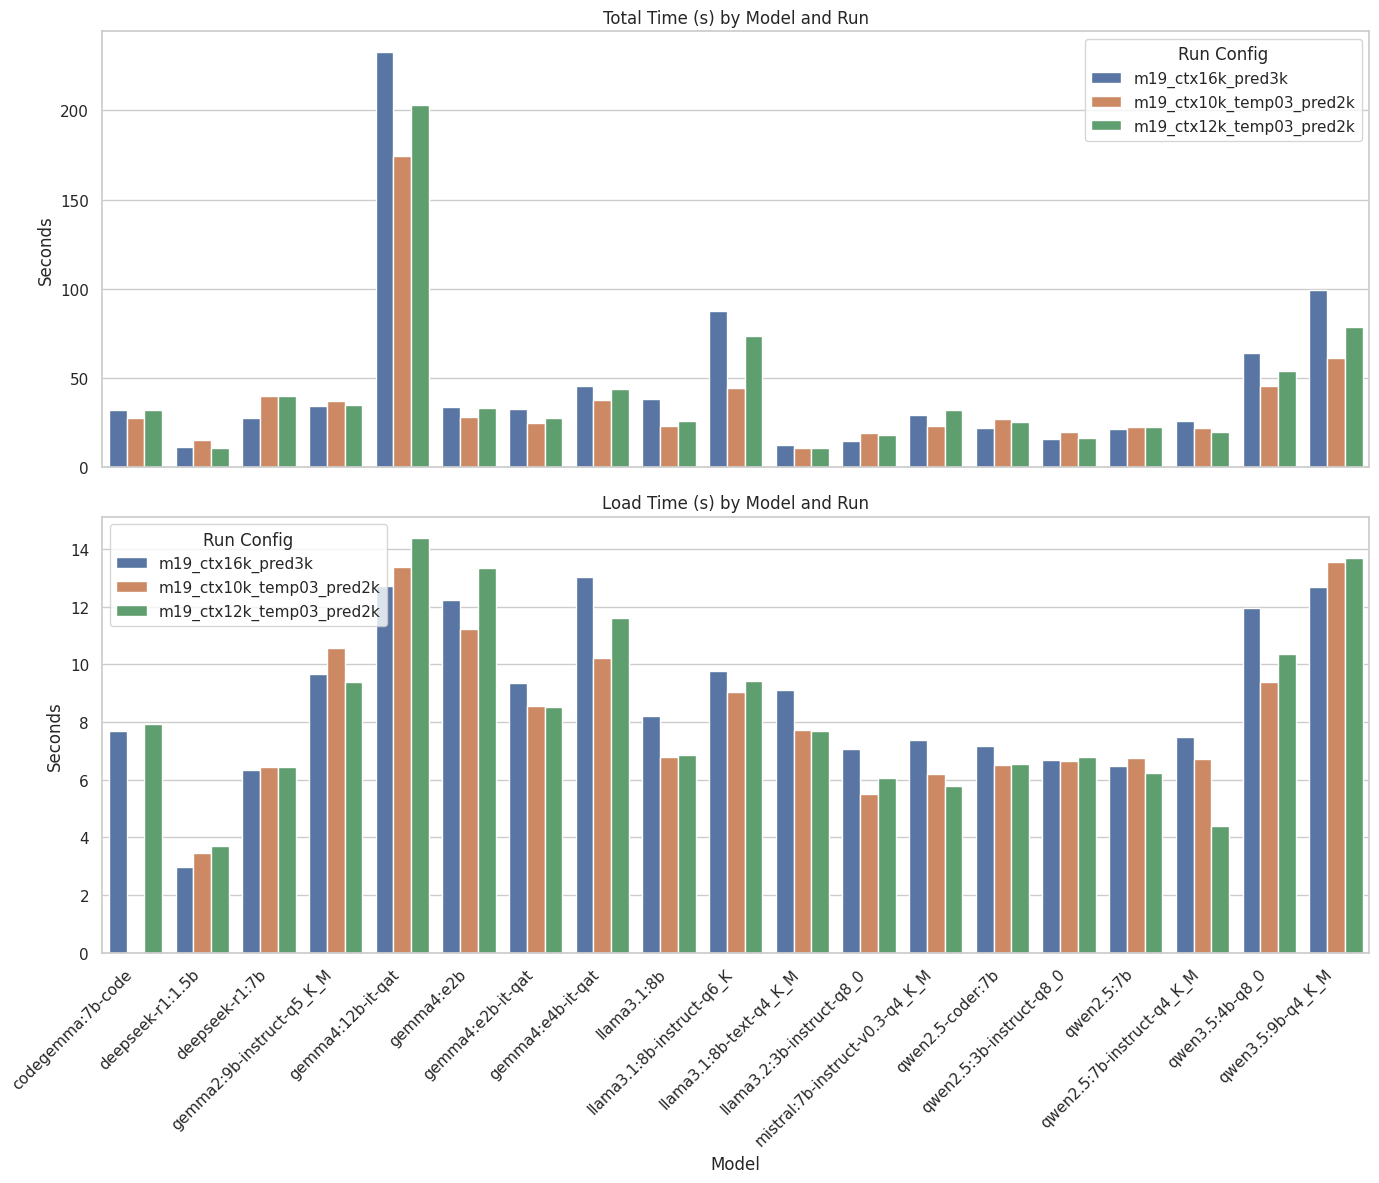

In [40]:
# 1. Total Time (s) and Load Time (s)
fig, axes = plt.subplots(2, 1, figsize=(14, 12), sharex=True)

sns.barplot(ax=axes[0], data=df_all, x="Model", y="Total Time (s)", hue="Run Name", order=unique_models)
axes[0].set_title("Total Time (s) by Model and Run")
axes[0].set_ylabel("Seconds")
axes[0].legend(title="Run Config")

sns.barplot(ax=axes[1], data=df_all, x="Model", y="Load Time (s)", hue="Run Name", order=unique_models)
axes[1].set_title("Load Time (s) by Model and Run")
axes[1].set_ylabel("Seconds")
axes[1].set_xlabel("Model")
axes[1].legend(title="Run Config")

plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

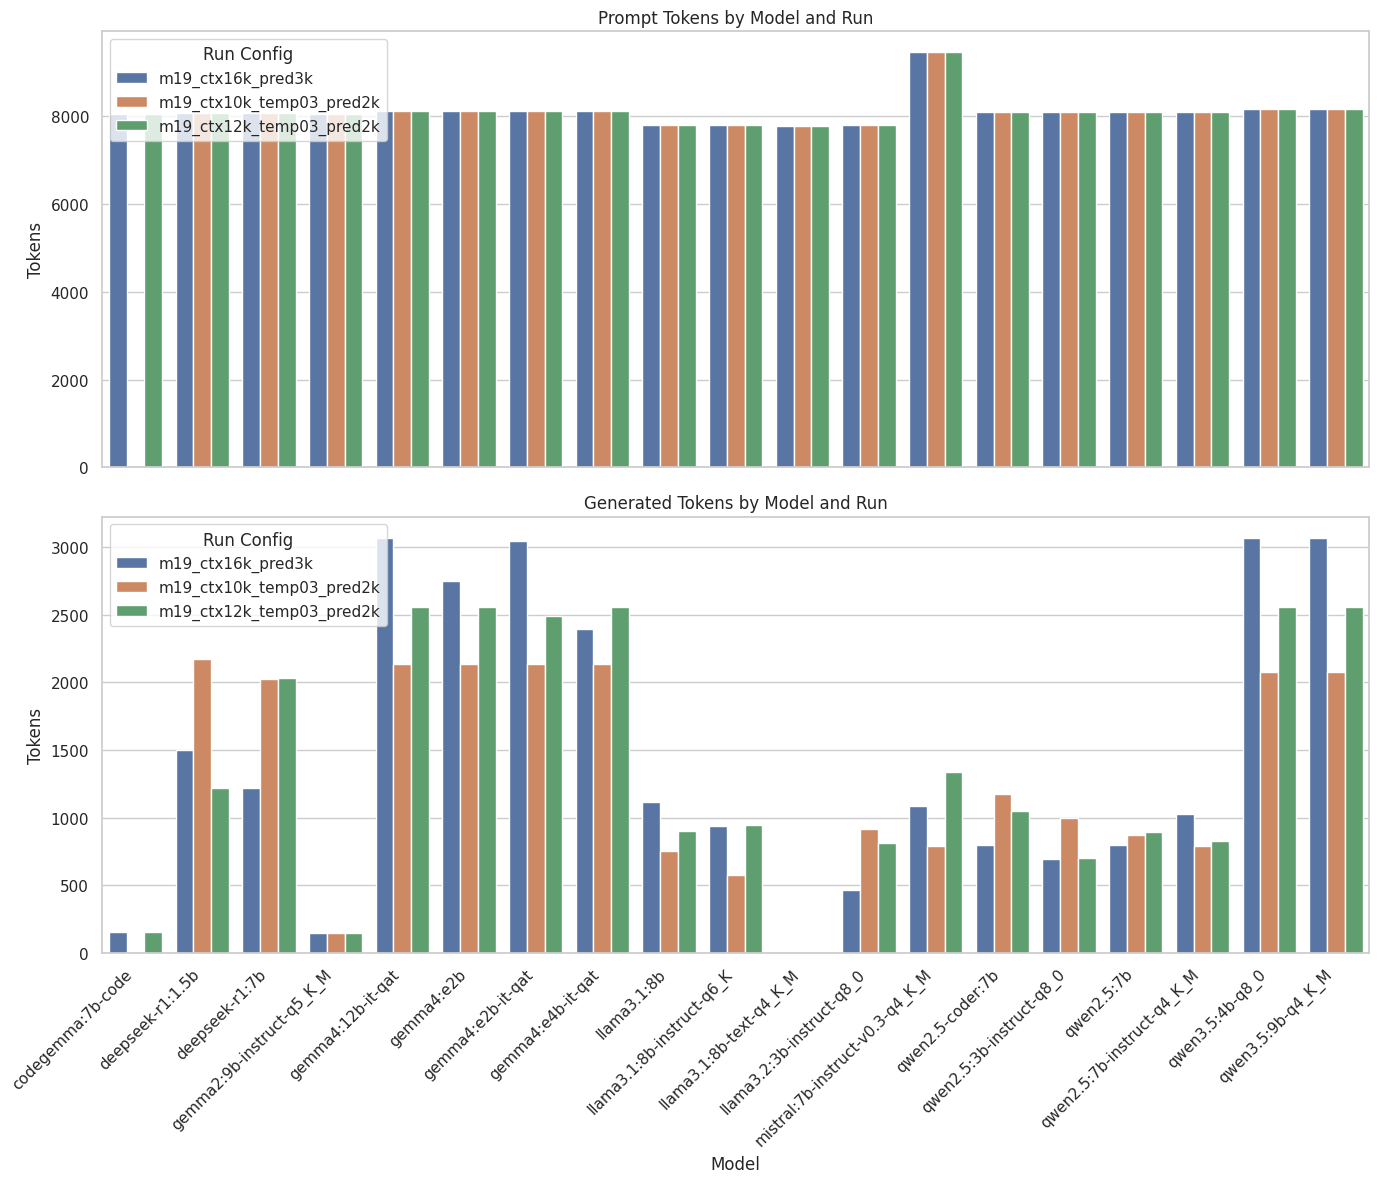

In [41]:
# 2. Prompt Tokens and Gen Tokens
fig, axes = plt.subplots(2, 1, figsize=(14, 12), sharex=True)

sns.barplot(ax=axes[0], data=df_all, x="Model", y="Prompt Tokens", hue="Run Name", order=unique_models)
axes[0].set_title("Prompt Tokens by Model and Run")
axes[0].set_ylabel("Tokens")
axes[0].legend(title="Run Config")

sns.barplot(ax=axes[1], data=df_all, x="Model", y="Gen Tokens", hue="Run Name", order=unique_models)
axes[1].set_title("Generated Tokens by Model and Run")
axes[1].set_ylabel("Tokens")
axes[1].set_xlabel("Model")
axes[1].legend(title="Run Config")

plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

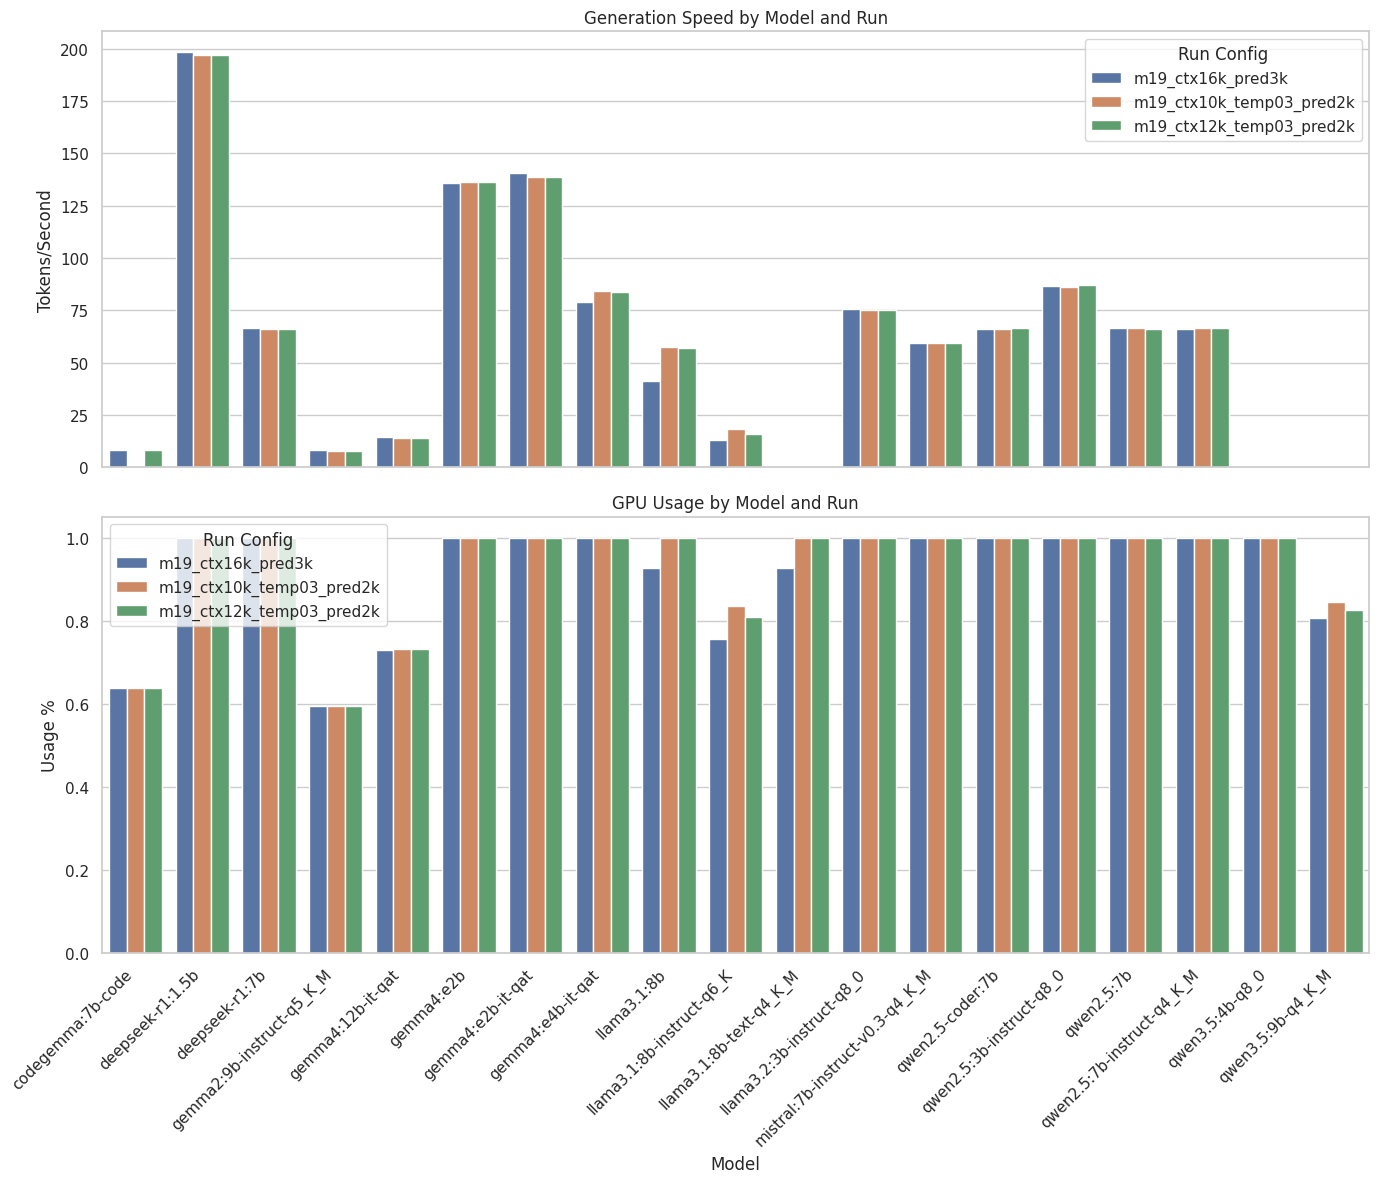

In [42]:
# 3. Gen Speed (t/s) and GPU Usage
fig, axes = plt.subplots(2, 1, figsize=(14, 12), sharex=True)

sns.barplot(ax=axes[0], data=df_all, x="Model", y="Gen Speed (t/s)", hue="Run Name", order=unique_models)
axes[0].set_title("Generation Speed by Model and Run")
axes[0].set_ylabel("Tokens/Second")
axes[0].legend(title="Run Config")

sns.barplot(ax=axes[1], data=df_all, x="Model", y="GPU Usage", hue="Run Name", order=unique_models)
axes[1].set_title("GPU Usage by Model and Run")
axes[1].set_ylabel("Usage %")
axes[1].set_xlabel("Model")
axes[1].legend(title="Run Config")

plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

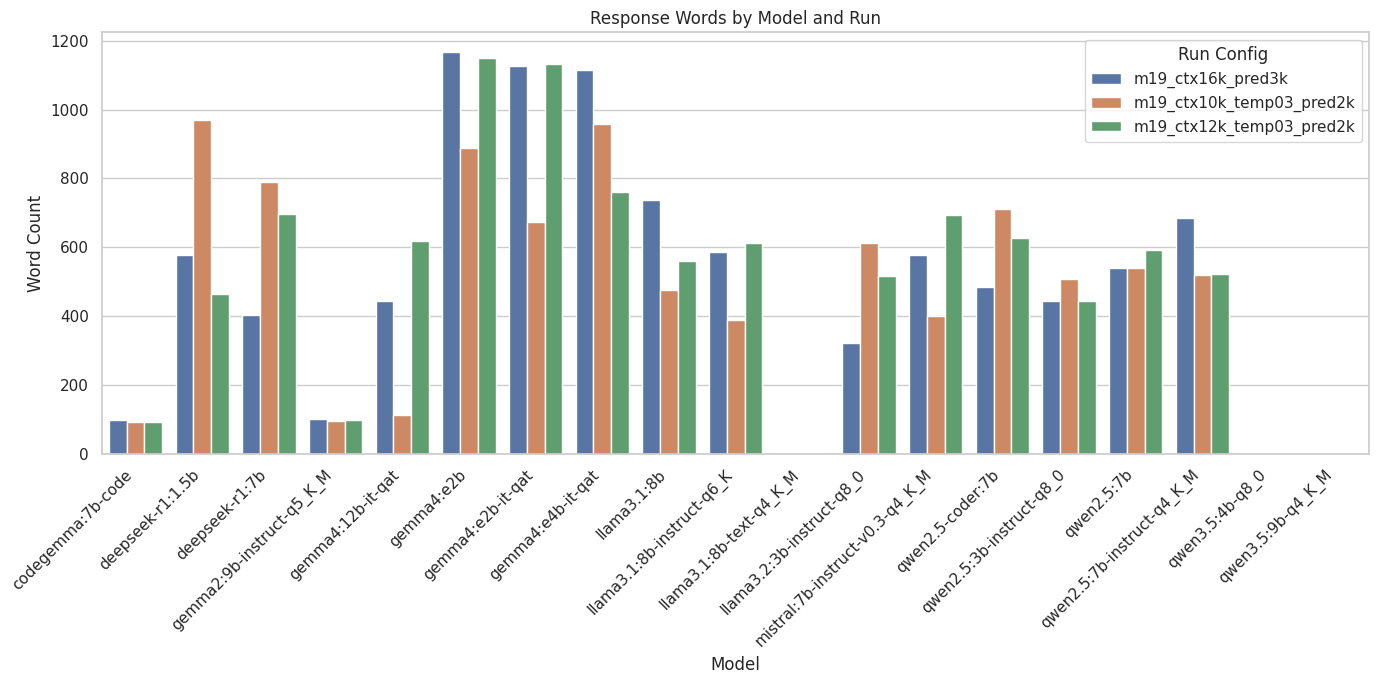

In [43]:
# 4. Response Words
plt.figure(figsize=(14, 7))
sns.barplot(data=df_all, x="Model", y="Response Words", hue="Run Name", order=unique_models)
plt.title("Response Words by Model and Run")
plt.ylabel("Word Count")
plt.xlabel("Model")
plt.legend(title="Run Config")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

In [79]:
# Filter models with bad performance
df_filtered = df_all[(df_all["GPU Usage"] == 1.0) & (df_all["Gen Speed (t/s)"] > 0)].copy()

THRESHOLD = 0.7
# Filter only ones that perform better then THRESHOLD
cols_inc = ['Gen Tokens', 'Response Words', 'Gen Speed (t/s)']
cols_dec = ['Total Time (s)']
q80_cols_inc = df_filtered[cols_inc].quantile(THRESHOLD)
q80_cols_dec = df_filtered[cols_dec].quantile(THRESHOLD)

print(cols_inc)
print(q80_cols_inc)
print(cols_dec)
print(q80_cols_inc)

cond_top = (df_filtered[cols_inc] > q80_cols_inc).any(axis=1)
cond_bottom = (df_filtered[cols_dec] < q80_cols_dec).any(axis=1)

df_filtered = df_filtered[cond_top & cond_bottom]

view_cols = ["Model", "Options", "Total Time (s)", "Gen Speed (t/s)", "Gen Tokens", "Response Words"]
table_df = df_filtered[view_cols].sort_values(['Gen Tokens'],ascending=False).reset_index(drop=True)
styled_df = (
    table_df.style
    .background_gradient(cmap="RdYlGn", subset=["Gen Tokens", "Response Words", "Gen Speed (t/s)"])
    .background_gradient(cmap="RdYlGn_r", subset=["Total Time (s)"])
)
display(styled_df)

['Gen Tokens', 'Response Words', 'Gen Speed (t/s)']
Gen Tokens         2033.400000
Response Words      709.200000
Gen Speed (t/s)      86.620456
Name: 0.7, dtype: float64
['Total Time (s)']
Gen Tokens         2033.400000
Response Words      709.200000
Gen Speed (t/s)      86.620456
Name: 0.7, dtype: float64


,Model,Options,Total Time (s),Gen Speed (t/s),Gen Tokens,Response Words
0,gemma4:e2b-it-qat,"ctx: 12288, pred: 2560, temp: 0.3",27.732111,138.703704,2495,1132
1,deepseek-r1:1.5b,"ctx: 10240, pred: 2560, temp: 0.3",15.372753,197.056420,2172,971
2,gemma4:e2b-it-qat,"ctx: 10240, pred: 2560, temp: 0.3",25.153889,138.861222,2138,672
3,deepseek-r1:1.5b,"ctx: 16384, pred: 3072",11.349172,198.315837,1499,578
4,deepseek-r1:1.5b,"ctx: 12288, pred: 2560, temp: 0.3",10.755859,197.024461,1217,463
5,qwen2.5-coder:7b,"ctx: 10240, pred: 2560, temp: 0.3",27.251250,66.209806,1177,712
6,qwen2.5:3b-instruct-q8_0,"ctx: 12288, pred: 2560, temp: 0.3",16.296294,86.959380,701,444
7,qwen2.5:3b-instruct-q8_0,"ctx: 16384, pred: 3072",16.098363,86.732006,693,444
